# Problem Statement

-> 1. Problem Understanding

1.1 Problem Statement

Food delivery performance can be affected by various operational and environmental
factors, such as delivery distance, preparation time, traffic conditions, weather,
time of day, vehicle type, and courier experience.

This analysis aims to understand how these factors are associated with delivery time
and identify the factors and patterns that are most relevant to delivery performance.

1.2 Analysis Objectives

The objectives of this analysis are:

1. Understand the distribution and characteristics of delivery time.
2. Analyze the relationship between delivery time and available operational factors.
3. Compare delivery performance across different traffic, weather, time-of-day,
   and vehicle categories.
4. Identify the factors and patterns most strongly associated with longer delivery times.
5. Translate the findings into actionable business recommendations.

# Data Preprocessing

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/TakeHomeTest_DABI22/dataset/Food_Delivery_Times.csv', sep=',')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.00,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.00,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.00,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.00,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.00,68


## Check ukuran dataset

In [4]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 1000
Jumlah kolom : 9


## Check Struktur dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


## Statistik Deskriptif

In [6]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,"1,000.00","1,000.00","1,000.00",970.00,"1,000.00"
mean,500.50,10.06,16.98,4.58,56.73
std,288.82,5.70,7.20,2.91,22.07
min,1.00,0.59,5.00,0.00,8.00
25%,250.75,5.11,11.00,2.00,41.00
50%,500.50,10.19,17.00,5.00,55.50
75%,750.25,15.02,23.00,7.00,71.00
max,"1,000.00",19.99,29.00,9.00,153.00


In [7]:
#kategorikal
df.describe(include='object')

,Weather,Traffic_Level,Time_of_Day,Vehicle_Type
count,970,970,970,1000
unique,5,3,4,3
top,Clear,Medium,Morning,Bike
freq,470,390,308,503


## Check missing value

In [8]:
#check missing value
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


Terdapat missing value pada variabel Weather (kategorik), Traffic_level(kategorik), Time_of_day(kategorik), dan courier_experience_yrs(numerik)

## Penanganan missing value

In [9]:
categorical_cols = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day"
]

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== Weather =====
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64

===== Traffic_Level =====
Traffic_Level
Medium    390
Low       383
High      197
NaN        30
Name: count, dtype: int64

===== Time_of_Day =====
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
NaN           30
Name: count, dtype: int64


Imputasi missing value pada ketiga variabel kategorik ini digunakan modus dari masing masing variabel. dimana untuk variabel weather diisi dengan "Clear", lalu traffic level diisi dengan "Medium", dan time of day diisi dengan "Morning"

In [10]:
df["Courier_Experience_yrs"].describe()

,Courier_Experience_yrs
count,970.00
mean,4.58
std,2.91
min,0.00
25%,2.00
50%,5.00
75%,7.00
max,9.00


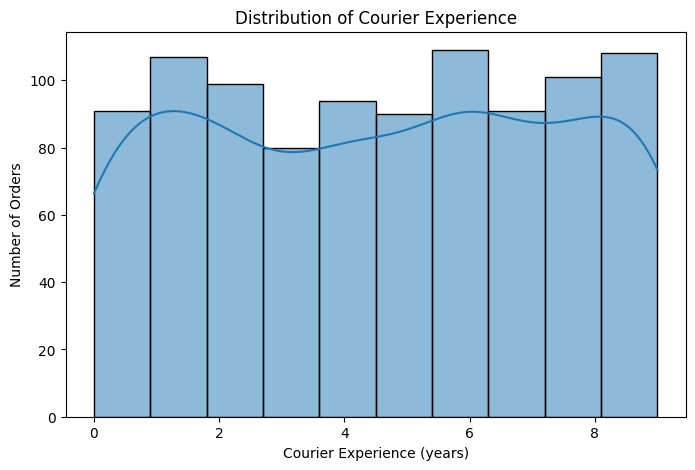

In [11]:
#histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Courier_Experience_yrs",
    bins=10,
    kde=True
)

plt.title("Distribution of Courier Experience")
plt.xlabel("Courier Experience (years)")
plt.ylabel("Number of Orders")

plt.show()

Imputasi missing value untuk variabel numerik ini adalah menggunakan median. Median yang diperoleh adalah 5 tahun, sehingga data yang kosong diisi dengan nilai 5. Median dipilih karena merupakan nilai tengah dari data yang tersedia dan relatif tidak terpengaruh oleh nilai yang terlalu rendah atau terlalu tinggi.

Mean sebenarnya juga bisa digunakan, karena distribusinya relatif merata dan mean dengan median juga cukup dekat. Saya memilih median karena lebih sederhana dan tidak terlalu sensitif terhadap nilai ekstrem (kalau ada beberapa angka yang jauh banget, median biasanya tetap relatif stabil.).

## Imputasi missing value

In [12]:
#copy data
df_clean = df.copy()

In [13]:
#kategorik imputasi dgn modus
for col in categorical_cols:
    mode_value = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_value)

In [14]:
#numerik imputasi dgn median
median_experience = df_clean["Courier_Experience_yrs"].median()

df_clean["Courier_Experience_yrs"] = (
    df_clean["Courier_Experience_yrs"]
    .fillna(median_experience)
)

In [15]:
#validasi missing value
df_clean.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


Berhasil dilakukan impmutasi pada missing value

## Duplicate

In [16]:
print("Jumlah duplicate rows:", df.duplicated().sum())
#check duplikat order id
print("Duplicate Order_ID:", df["Order_ID"].duplicated().sum())

Jumlah duplicate rows: 0
Duplicate Order_ID: 0


In [17]:
# check data types
df_clean.dtypes

,0
Order_ID,int64
Distance_km,float64
Weather,object
Traffic_Level,object
Time_of_Day,object
Vehicle_Type,object
Preparation_Time_min,int64
Courier_Experience_yrs,float64
Delivery_Time_min,int64


In [18]:
#check konsistensi tipe data ((masih dipertimbangkan untuk masuk ke hasil))
categorical_check = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
]

for col in categorical_check:
    print(f"\n===== {col} =====")
    print(df_clean[col].value_counts())


===== Weather =====
Weather
Clear    500
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

===== Traffic_Level =====
Traffic_Level
Medium    420
Low       383
High      197
Name: count, dtype: int64

===== Time_of_Day =====
Time_of_Day
Morning      338
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64

===== Vehicle_Type =====
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


In [19]:
#numeric validation
numeric_cols = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delivery_Time_min"
]

df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Distance_km,"1,000.00",10.06,5.70,0.59,5.11,10.19,15.02,19.99
Preparation_Time_min,"1,000.00",16.98,7.20,5.00,11.00,17.00,23.00,29.00
Courier_Experience_yrs,"1,000.00",4.59,2.87,0.00,2.00,5.00,7.00,9.00
Delivery_Time_min,"1,000.00",56.73,22.07,8.00,41.00,55.50,71.00,153.00


In [20]:
#check nilai negatif
for col in numeric_cols:
    negative_count = (df_clean[col] < 0).sum()

    print(
        f"{col}: {negative_count} negative values"
    )

Distance_km: 0 negative values
Preparation_Time_min: 0 negative values
Courier_Experience_yrs: 0 negative values
Delivery_Time_min: 0 negative values


## Outlier detection

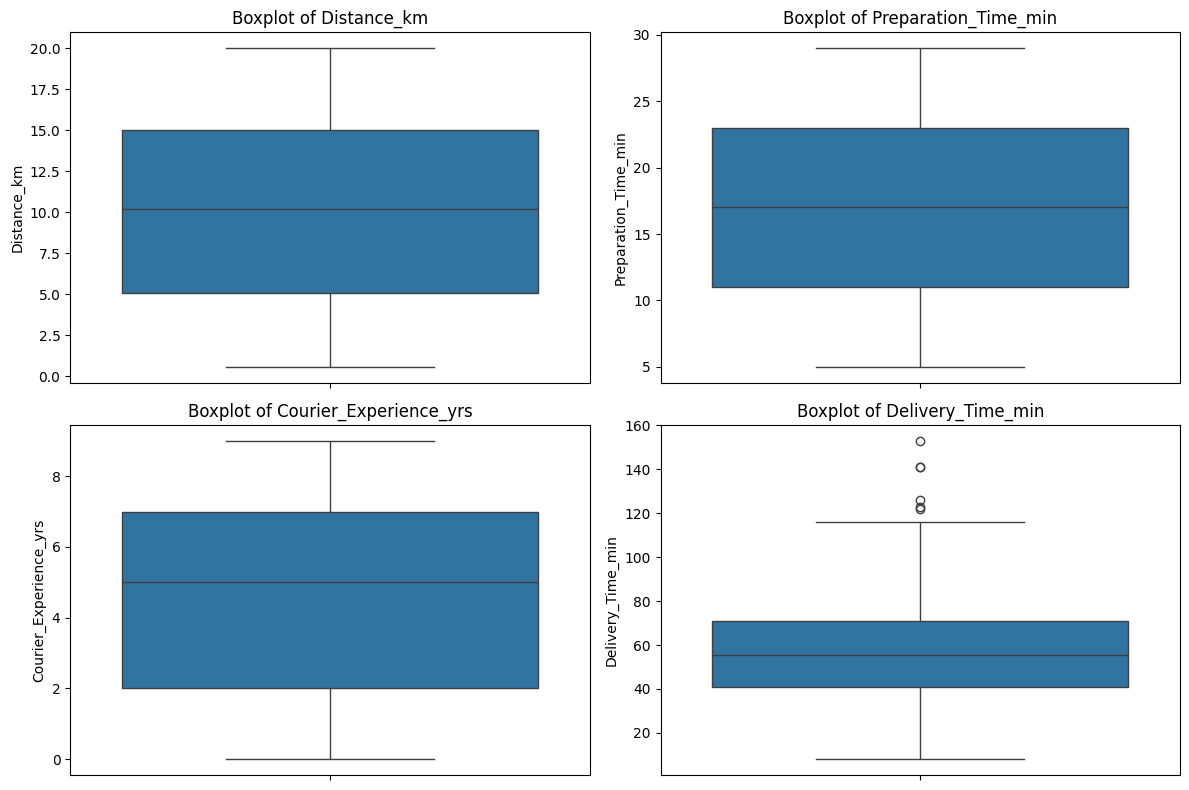

In [21]:
#boxplot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df_clean[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [22]:
outlier_results = []

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    outlier_results.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Distance_km,5.11,15.02,9.91,-9.76,29.89,0
1,Preparation_Time_min,11.00,23.00,12.00,-7.00,41.00,0
2,Courier_Experience_yrs,2.00,7.00,5.00,-5.50,14.50,0
3,Delivery_Time_min,41.00,71.00,30.00,-4.00,116.00,6


Outlier pada variabel numerik diidentifikasi menggunakan metode Interquartile Range (IQR).

Berdasarkan hasil deteksi, terdapat 6 outlier pada variabel Delivery_Time_min. Sementara itu, tidak ditemukan outlier berdasarkan metode IQR pada Distance_km, Preparation_Time_min, dan Courier_Experience_yrs berdasarkan metode IQR.

In [23]:
#check 6 outlier
delivery_outliers = df_clean[
    df_clean["Delivery_Time_min"] > (
        df_clean["Delivery_Time_min"].quantile(0.75)
        + 1.5 * (
            df_clean["Delivery_Time_min"].quantile(0.75)
            - df_clean["Delivery_Time_min"].quantile(0.25)
        )
    )
]

delivery_outliers[
    [
        "Order_ID",
        "Distance_km",
        "Weather",
        "Traffic_Level",
        "Time_of_Day",
        "Vehicle_Type",
        "Preparation_Time_min",
        "Courier_Experience_yrs",
        "Delivery_Time_min"
    ]
].sort_values(
    "Delivery_Time_min",
    ascending=False
)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
379,814,18.46,Clear,Medium,Morning,Scooter,29,1.00,153
127,446,18.97,Clear,Low,Evening,Car,25,4.00,141
452,394,15.64,Rainy,Low,Morning,Bike,20,4.00,141
784,385,14.83,Rainy,Low,Morning,Car,19,4.00,126
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.00,123
924,428,17.81,Windy,High,Evening,Bike,21,4.00,122


Berdasarkan metode IQR, terdapat 6 data yang teridentifikasi sebagai outlier pada variabel Delivery_Time_min.

setelah di check menunjukkan bahwa keenam data memiliki jarak pengiriman yang relatif jauh, yaitu sekitar 14,83km - 18,97 km. Beberapa data juga memiliki preparation time yang cukup tinggi atau berada pada kondisi traffic tertentu.

Oleh karena itu, keenam outlier dipertahankan dalam dataset karena masih dapat merepresentasikan kondisi operasional yang terjadi dalam proses pengiriman.

## Feature Engineering

Pada feature engineering dibuat distance category untuk mengelompokkan jarak pengiriman ke beberapa rentang agar perbedaan rata-rata delivery time antar kelompok jarak lebih mudah dibandingkan dan diinterpretasikan.

In [24]:
#distance_category
bins = [
    0,
    5,
    10,
    15,
    np.inf
]

labels = [
    "0-5 km",
    "5-10 km",
    "10-15 km",
    "15+ km"
]

df_clean["Distance_Category"] = pd.cut(
    df_clean["Distance_km"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [25]:
df_clean["Distance_Category"].value_counts().sort_index()

,count
Distance_Category,
0-5 km,248
5-10 km,241
10-15 km,260
15+ km,251


bins menentukan batas dan urutan kelompok

labels menentukan nama kelompoknya

pd.cut() membagi data numerik ke dalam interval berdasarkan bins dan memberikan label sesuai urutan tersebut.

Distance category dibuat berdasarkan nilai Distance_km dengan membagi jarak menjadi beberapa rentang agar perbandingan delivery time antar kelompok lebih mudah dilakukan.

In [26]:
#final check dataset
print("Dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isna().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nData types:")
print(df_clean.dtypes)

Dataset shape: (1000, 10)

Missing values:
Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
Distance_Category         0
dtype: int64

Duplicate rows:
0

Data types:
Order_ID                     int64
Distance_km                float64
Weather                     object
Traffic_Level               object
Time_of_Day                 object
Vehicle_Type                object
Preparation_Time_min         int64
Courier_Experience_yrs     float64
Delivery_Time_min            int64
Distance_Category         category
dtype: object


In [27]:
df_clean.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Distance_Category
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.00,43,5-10 km
1,738,16.42,Clear,Medium,Evening,Bike,20,2.00,84,15+ km
2,741,9.52,Foggy,Low,Night,Scooter,28,1.00,59,5-10 km
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.00,37,5-10 km
4,412,19.03,Clear,Low,Morning,Bike,16,5.00,68,15+ km


# EDA

## Statistik Deskriptif

In [28]:
descriptive_cols = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delivery_Time_min"
]

df_clean[descriptive_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Distance_km,"1,000.00",10.06,5.70,0.59,5.11,10.19,15.02,19.99
Preparation_Time_min,"1,000.00",16.98,7.20,5.00,11.00,17.00,23.00,29.00
Courier_Experience_yrs,"1,000.00",4.59,2.87,0.00,2.00,5.00,7.00,9.00
Delivery_Time_min,"1,000.00",56.73,22.07,8.00,41.00,55.50,71.00,153.00


Analisis ini digunakan untuk memahami karakteristik dasar variabel numerik, seperti nilai rata-rata, median, nilai minimum, maksimum, dan penyebaran data.

Variabel yang dianalisis adalah Distance_km, Preparation_Time_min, Courier_Experience_yrs, dan Delivery_Time_min.

## Distribusi data untuk setiap variabel

### Delivery Time Distribution

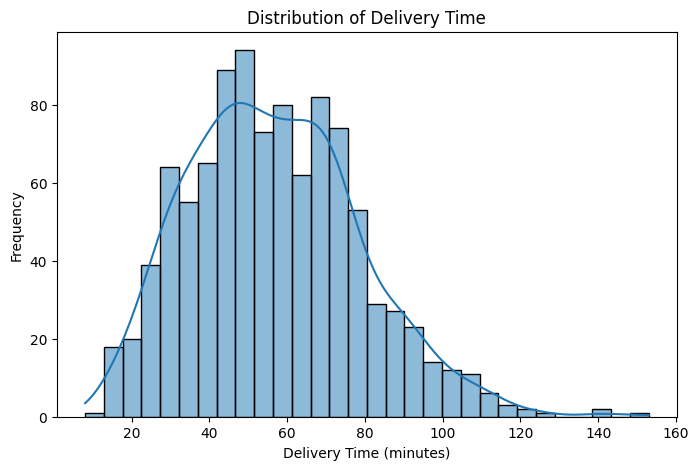

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="Delivery_Time_min",
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")

#save visualisasi
plt.savefig(
    "Distribution_of_Delivery_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Distribusi Delivery_Time_min menunjukkan bahwa sebagian besar order berada pada rentang delivery time yang relatif moderat, dengan beberapa observasi memiliki delivery time yang jauh lebih tinggi.

Observasi dengan delivery time yang sangat tinggi kemudian diperiksa lebih lanjut pada tahap outlier analysis.

### Numerical Variable Distribution

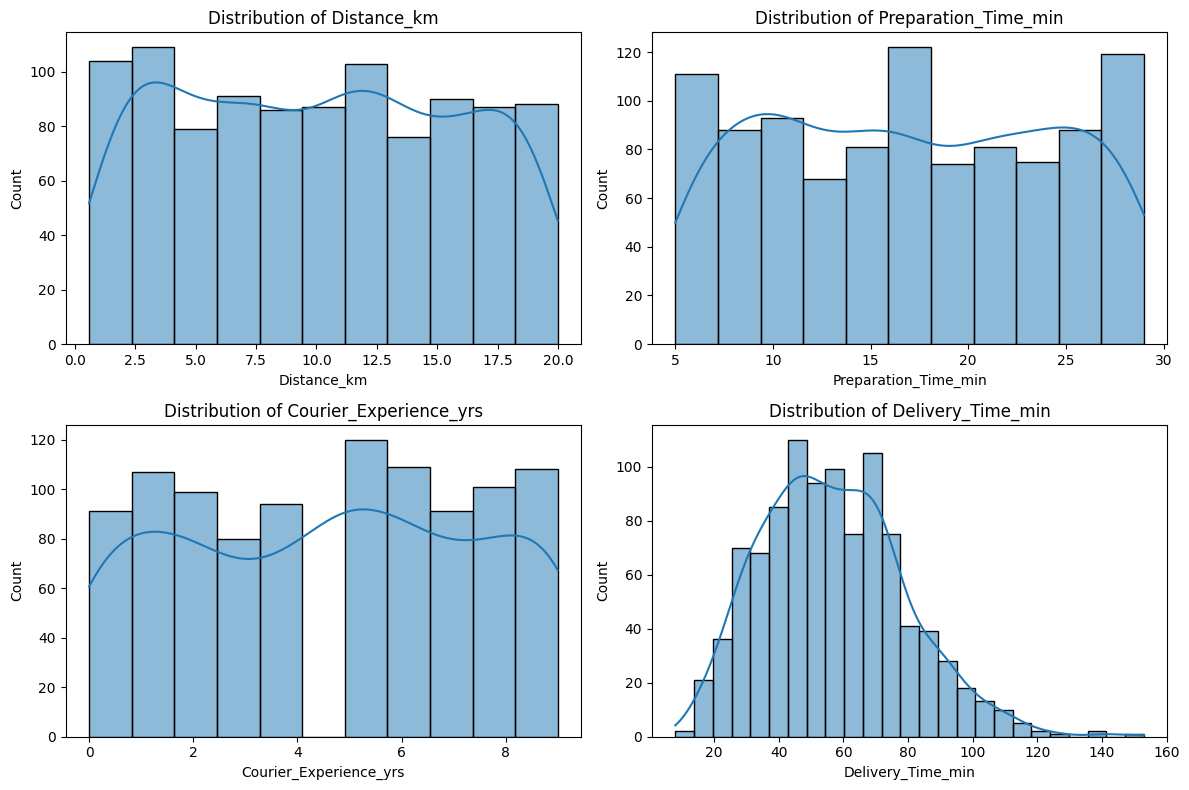

In [30]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8)
)

for ax, col in zip(axes.flatten(), numeric_cols):

    sns.histplot(
        data=df_clean,
        x=col,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

Distance_km tersebar pada rentang sekitar 0,59–19,99 km, Preparation_Time_min berada pada rentang 5–29 menit, sedangkan Courier_Experience_yrs berada pada rentang 0–9 tahun.

Distribusi ini memberikan gambaran awal mengenai variasi masing-masing faktor yang tersedia dalam dataset.

### Categorical Distribution

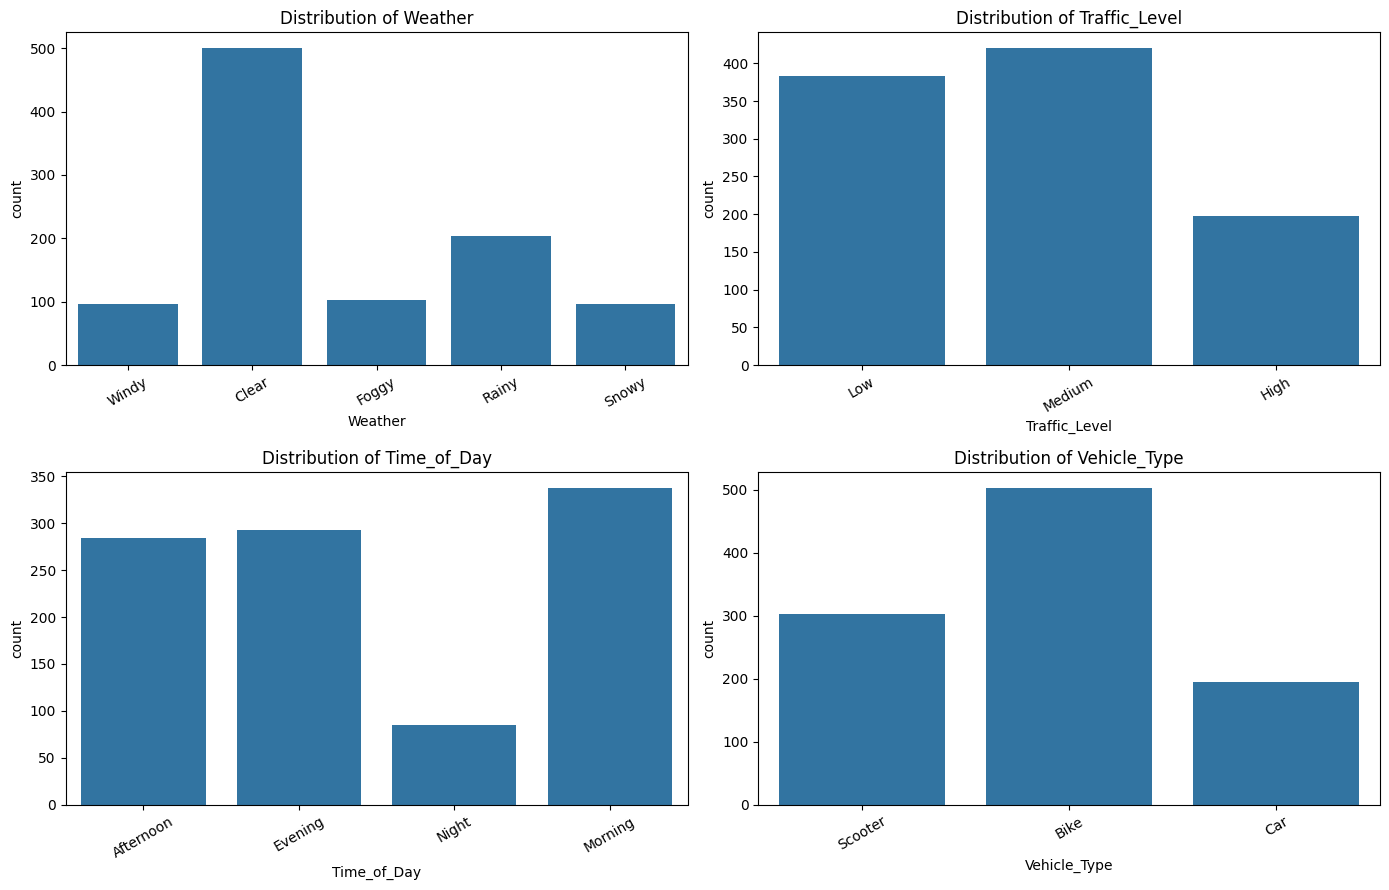

In [31]:
categorical_cols_all = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9)
)

for ax, col in zip(
    axes.flatten(),
    categorical_cols_all
):

    sns.countplot(
        data=df_clean,
        x=col,
        ax=ax
    )

    ax.set_title(f"Distribution of {col}")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Dataset memiliki variasi pada seluruh kategori yang digunakan dalam analisis.

Setelah proses imputasi, kategori yang paling banyak ditemukan adalah Clear untuk Weather, Medium untuk Traffic_Level, Morning untuk Time_of_Day, dan Bike untuk Vehicle_Type.

Distribusi kategori ini perlu diperhatikan ketika membandingkan rata-rata delivery time antar kelompok.

## Analisis Hubungan Antar Variabel

### Traffic level vs Delivery time

Tujuannya adalah melihat apakah terdapat perbedaan delivery time antara kondisi traffic Low, Medium, dan High.

In [32]:
traffic_summary = (
    df_clean
    .groupby("Traffic_Level")["Delivery_Time_min"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

traffic_summary

,count,mean,median
Traffic_Level,,,
High,197,64.81,65.00
Medium,420,56.45,54.00
Low,383,52.89,51.00


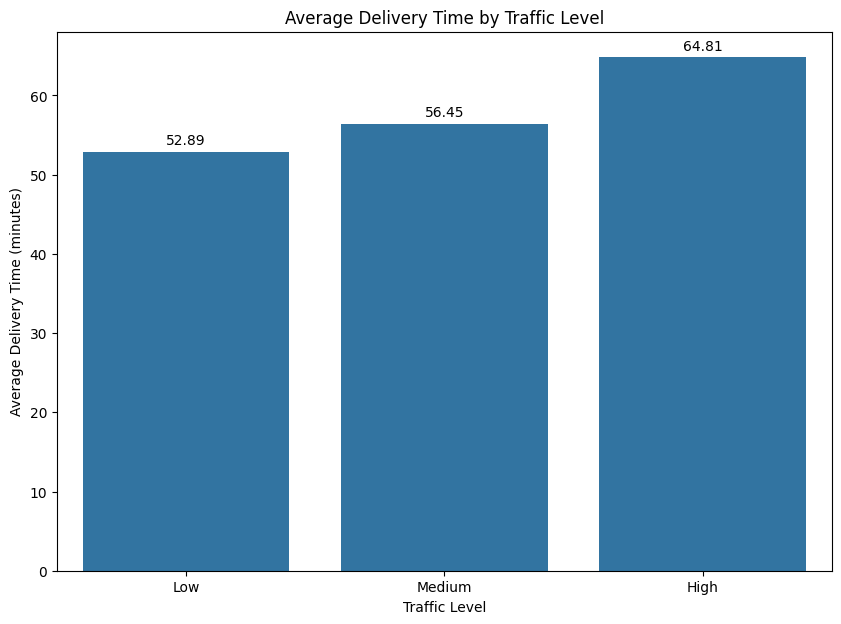

In [33]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=df_clean,
    x="Traffic_Level",
    y="Delivery_Time_min",
    estimator="mean",
    errorbar=None
)

plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")

# Menambahkan data label
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

#save visualisasi
plt.savefig(
    "Average_Delivery_Time_by_Traffic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Rata-rata delivery time meningkat seiring dengan meningkatnya traffic level.

- Low: 52,89 menit
- Medium: 56,45 menit
- High: 64,81 menit

Kondisi High Traffic memiliki rata-rata delivery time paling tinggi dibandingkan kategori lainnya. Hal ini menunjukkan adanya hubungan antara traffic level dan delivery time pada dataset.

### Weather vs Delivery time

Tujuannya adalah melihat apakah terdapat perbedaan delivery performance pada kondisi cuaca yang berbeda.

In [34]:
weather_summary = (
    df_clean
    .groupby("Weather")["Delivery_Time_min"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

weather_summary

,count,mean,median
Weather,,,
Snowy,97,67.11,66.00
Rainy,204,59.79,57.50
Foggy,103,59.47,59.00
Windy,96,55.46,55.00
Clear,500,53.15,52.00


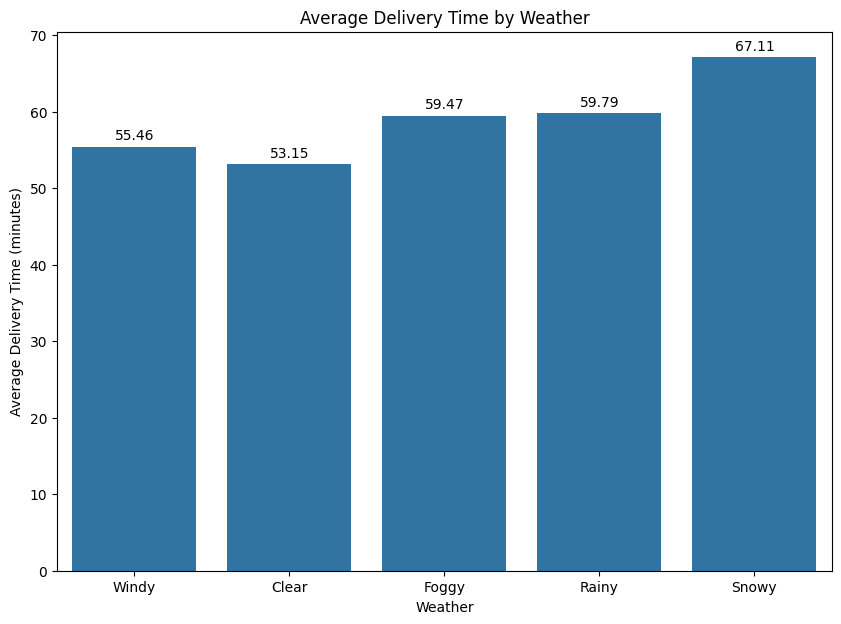

In [35]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=df_clean,
    x="Weather",
    y="Delivery_Time_min",
    estimator="mean",
    errorbar=None
)

plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (minutes)")

# Menambahkan data label
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

#save visualisasi
plt.savefig(
    "Average_Delivery_Time_by_Weather.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Terdapat perbedaan rata-rata delivery time antar kondisi weather.

Snowy memiliki rata-rata delivery time tertinggi sebesar 67,11 menit, sedangkan Clear memiliki rata-rata terendah sebesar 53,15 menit.

Hasil ini menunjukkan bahwa weather memiliki pola perbedaan delivery time pada dataset, dengan kondisi Snowy menunjukkan rata-rata delivery time yang lebih tinggi.

### Time of Day vs Delivery Time

Analisis ini digunakan untuk membandingkan rata-rata delivery time berdasarkan periode waktu pengiriman.

In [36]:
time_summary = (
    df_clean
    .groupby("Time_of_Day")["Delivery_Time_min"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

time_summary

,count,mean,median
Time_of_Day,,,
Evening,293,57.48,56.00
Morning,338,57.01,56.50
Afternoon,284,56.08,56.00
Night,85,55.21,52.00


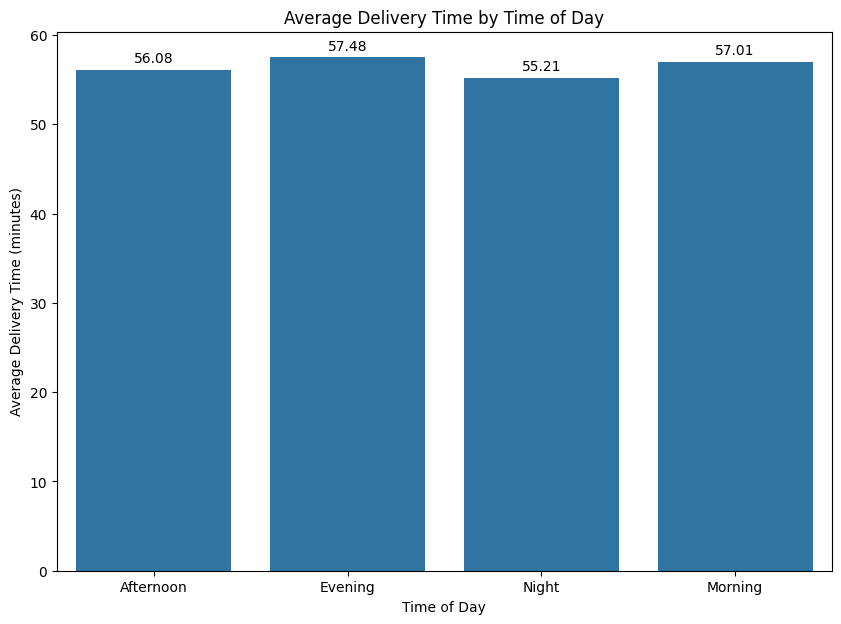

In [37]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=df_clean,
    x="Time_of_Day",
    y="Delivery_Time_min",
    estimator="mean",
    errorbar=None
)

plt.title("Average Delivery Time by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Delivery Time (minutes)")

# Menambahkan data label
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

#save visualisasi
plt.savefig(
    "Average_Delivery_Time_by_Time_of_Day.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Perbedaan rata-rata delivery time antar waktu pengiriman relatif kecil.

Evening memiliki rata-rata tertinggi sebesar 57,48 menit, sedangkan Night memiliki rata-rata terendah sebesar 55,21 menit.

Rentang perbedaan antar kategori relatif kecil dibandingkan dengan perbedaan yang terlihat pada beberapa faktor lainnya.

### Vehicle Type vs Delivery Time

Analisis ini digunakan untuk membandingkan rata-rata delivery time berdasarkan jenis kendaraan yang digunakan.

In [38]:
vehicle_summary = (
    df_clean
    .groupby("Vehicle_Type")["Delivery_Time_min"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

vehicle_summary

,count,mean,median
Vehicle_Type,,,
Car,195,58.20,56.00
Bike,503,56.57,56.00
Scooter,302,56.05,54.50


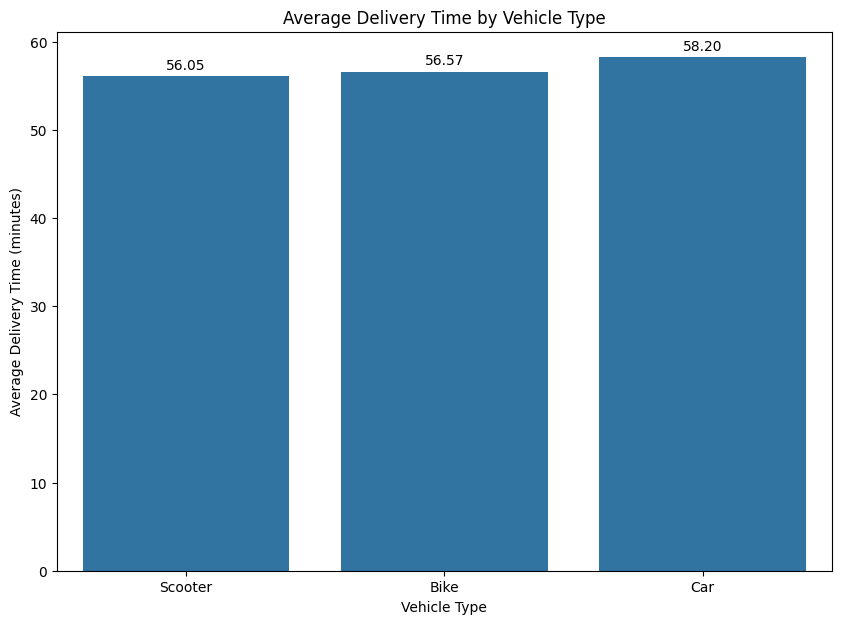

In [39]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=df_clean,
    x="Vehicle_Type",
    y="Delivery_Time_min",
    estimator="mean",
    errorbar=None
)

plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")

# Menambahkan data label
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

#save visualisasi
plt.savefig(
    "Average_Delivery_Time_by_Vehicle_Type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Perbedaan rata-rata delivery time antar vehicle type relatif kecil.

Car memiliki rata-rata delivery time sebesar 58,20 menit, Bike sebesar 56,57 menit, dan Scooter sebesar 56,05 menit.

Perbedaan ini menunjukkan bahwa vehicle type memiliki variasi rata-rata delivery time yang relatif kecil dibandingkan dengan faktor seperti distance dan traffic.

### Distance vs Delivery Time

Tujuannya adalah melihat apakah terdapat pola peningkatan delivery time ketika jarak pengiriman bertambah.

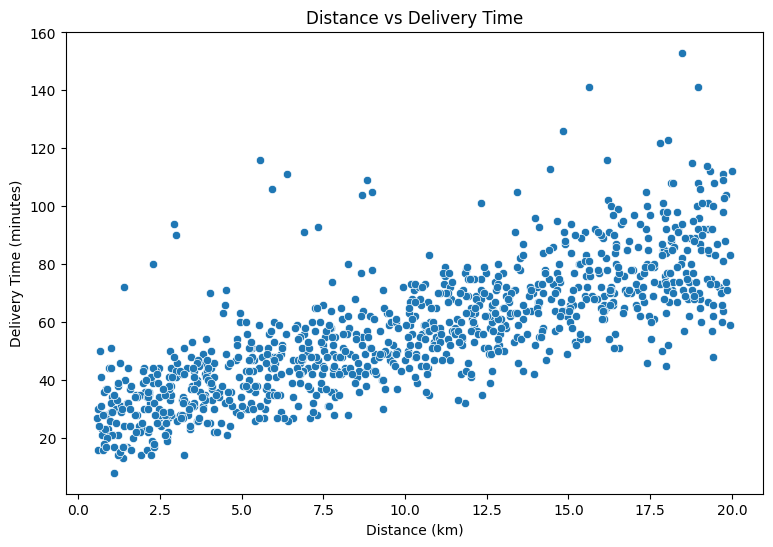

In [40]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Distance_km",
    y="Delivery_Time_min"
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

#save visualisasi
plt.savefig(
    "Distance_vs_Delivery_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Scatter plot menunjukkan pola hubungan positif antara Distance_km dan Delivery_Time_min. Secara umum, order dengan jarak pengiriman yang lebih jauh cenderung memiliki delivery time yang lebih tinggi.

Pola ini kemudian diperkuat melalui analisis correlation, di mana Distance_km memiliki korelasi sebesar 0,78 dengan Delivery_Time_min.

semakin jauh jaraknya, delivery time cenderung semakin tinggi. Jadi ada hubungan positif yang cukup kuat.

### Preparation Time vs Delivery Time

digunakan untuk melihat hubungan antara waktu persiapan makanan dan total delivery time.

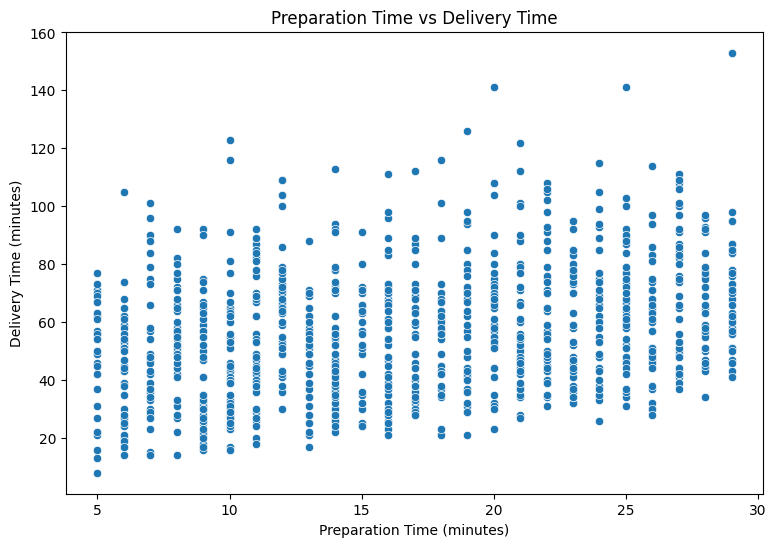

In [41]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Preparation_Time_min",
    y="Delivery_Time_min"
)

plt.title("Preparation Time vs Delivery Time")
plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Delivery Time (minutes)")

#save visualisasi
plt.savefig(
    "Preparation_Time_vs_Delivery_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Terdapat kecenderungan hubungan positif antara Preparation_Time_min dan Delivery_Time_min, meskipun pola hubungan tidak sekuat Distance_km.

Correlation antara Preparation_Time_min dan Delivery_Time_min sebesar 0,31, yang menunjukkan hubungan positif dengan kekuatan yang lebih rendah dibandingkan Distance_km.

### Courier Experience vs Delivery Time

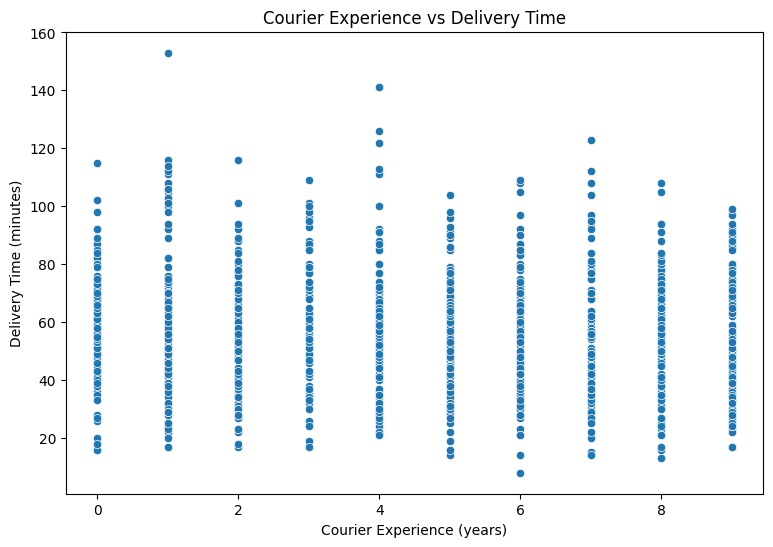

In [42]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Courier_Experience_yrs",
    y="Delivery_Time_min"
)

plt.title("Courier Experience vs Delivery Time")
plt.xlabel("Courier Experience (years)")
plt.ylabel("Delivery Time (minutes)")

#save visualisasi
plt.savefig(
    "Courier_Experience_vs_Delivery_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Hubungan antara Courier_Experience_yrs dan Delivery_Time_min terlihat relatif lemah.

Nilai correlation sebesar -0,09 menunjukkan hubungan negatif yang sangat lemah. Dengan demikian, courier experience tidak menunjukkan pola hubungan yang kuat dengan delivery time dibandingkan distance atau preparation time pada dataset ini.

### Correlation Analysis

Correlation analysis digunakan untuk mengukur kekuatan dan arah hubungan linear antar variabel numerik.

In [43]:
correlation_cols = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delivery_Time_min"
]

corr_matrix = df_clean[correlation_cols].corr()

corr_matrix

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Distance_km,1.00,-0.01,-0.01,0.78
Preparation_Time_min,-0.01,1.00,-0.03,0.31
Courier_Experience_yrs,-0.01,-0.03,1.00,-0.09
Delivery_Time_min,0.78,0.31,-0.09,1.00


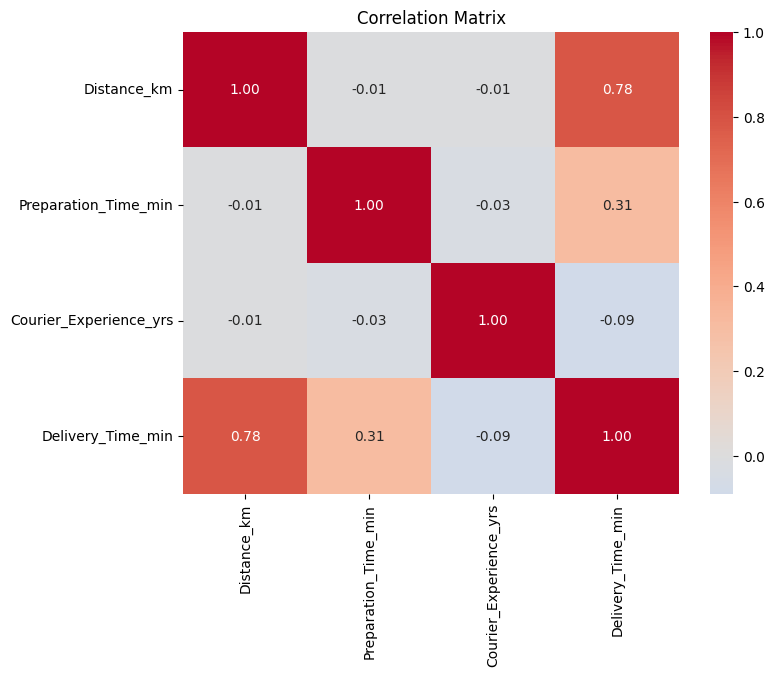

In [44]:
#heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

#save visualisasi
plt.savefig(
    "Correlation_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Distance_km memiliki korelasi positif paling kuat dengan Delivery_Time_min sebesar 0,78.

Preparation_Time_min memiliki korelasi positif sebesar 0,31, sedangkan Courier_Experience_yrs memiliki korelasi negatif yang lemah sebesar -0,09.

Hasil ini menunjukkan bahwa, di antara variabel numerik yang tersedia, Distance_km memiliki hubungan linear paling kuat dengan delivery time.

In [45]:
target_correlation = (
    corr_matrix["Delivery_Time_min"]
    .drop("Delivery_Time_min")
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_correlation

,Delivery_Time_min
Distance_km,0.78
Preparation_Time_min,0.31
Courier_Experience_yrs,-0.09


Berdasarkan nilai absolut korelasi terhadap Delivery_Time_min:

1. Distance_km: 0,78
2. Preparation_Time_min: 0,31
3. Courier_Experience_yrs: -0,09

Distance_km menjadi variabel numerik dengan hubungan paling kuat terhadap Delivery_Time_min.

### Distance Category vs Delivery Time

Distance_Category digunakan untuk melihat perbedaan rata-rata delivery time pada beberapa kelompok jarak.

In [46]:
distance_summary = (
    df_clean
    .groupby(
        "Distance_Category",
        observed=True
    )["Delivery_Time_min"]
    .agg(["count", "mean", "median"])
)

distance_summary

,count,mean,median
Distance_Category,,,
0-5 km,248,34.33,34.00
5-10 km,241,49.03,48.00
10-15 km,260,63.36,63.00
15+ km,251,79.40,77.00


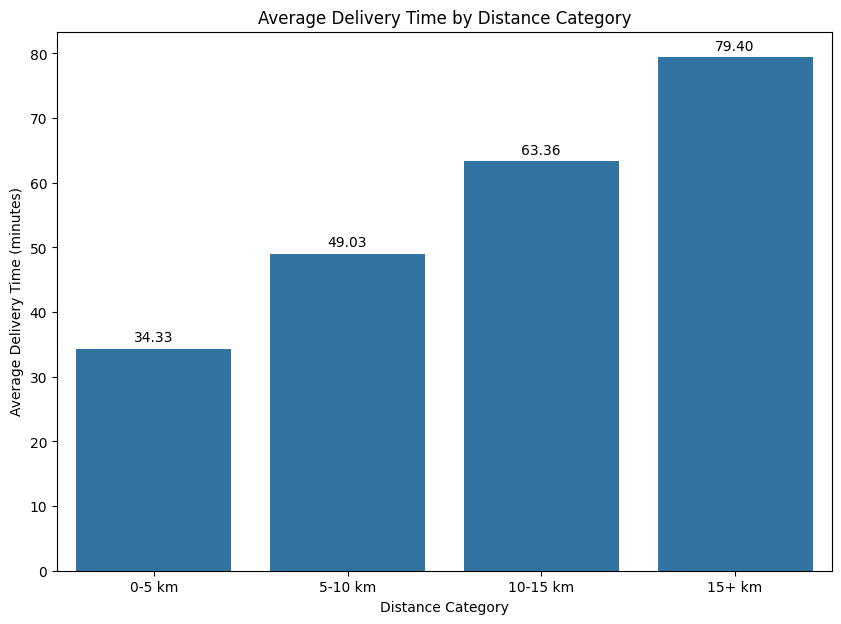

In [47]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=df_clean,
    x="Distance_Category",
    y="Delivery_Time_min",
    estimator="mean",
    errorbar=None,
    order=[
        "0-5 km",
        "5-10 km",
        "10-15 km",
        "15+ km"
    ]
)

plt.title("Average Delivery Time by Distance Category")
plt.xlabel("Distance Category")
plt.ylabel("Average Delivery Time (minutes)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

#save visualisasi
plt.savefig(
    "Average_Delivery_Time_by_Distance_Category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Terdapat pola peningkatan rata-rata delivery time seiring dengan meningkatnya distance category.

- 0–5 km: 34,33 menit
- 5–10 km: 49,03 menit
- 10–15 km: 63,36 menit
- 15+ km: 79,40 menit

Pola tersebut menunjukkan bahwa order dengan jarak yang lebih jauh cenderung memiliki delivery time yang lebih tinggi.

### Distance x Traffic

In [48]:
distance_traffic = (
    df_clean
    .groupby(
        ["Distance_Category", "Traffic_Level"],
        observed=True
    )["Delivery_Time_min"]
    .mean()
    .reset_index()
)

distance_traffic

,Distance_Category,Traffic_Level,Delivery_Time_min
0,0-5 km,High,41.66
1,0-5 km,Low,30.23
2,0-5 km,Medium,34.58
3,5-10 km,High,57.79
4,5-10 km,Low,44.89
5,5-10 km,Medium,49.28
6,10-15 km,High,68.83
7,10-15 km,Low,58.69
8,10-15 km,Medium,64.39
9,15+ km,High,86.92


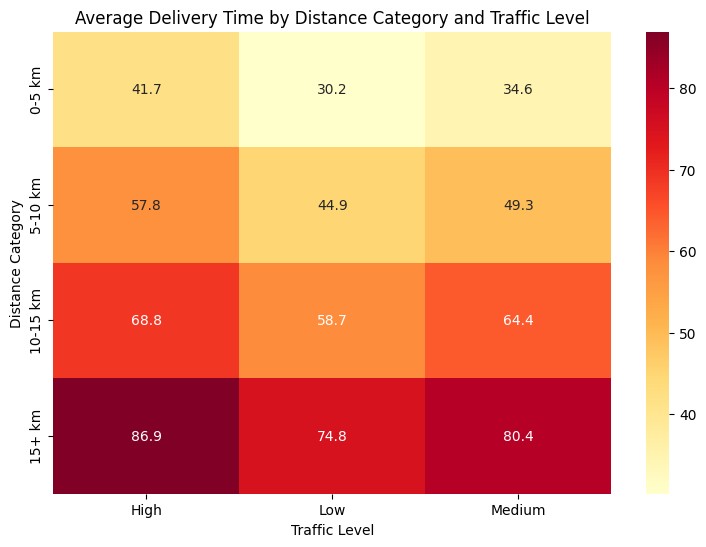

In [49]:
distance_traffic_pivot = (
    df_clean
    .pivot_table(
        index="Distance_Category",
        columns="Traffic_Level",
        values="Delivery_Time_min",
        aggfunc="mean",
        observed=True
    )
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    distance_traffic_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title(
    "Average Delivery Time by Distance Category and Traffic Level"
)

plt.xlabel("Traffic Level")
plt.ylabel("Distance Category")

#save visualisasi
plt.savefig(
    "Average_Delivery_Time_by_Distance_Category_and_Traffic_Level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Pada seluruh distance category, rata-rata delivery time pada kondisi High Traffic lebih tinggi dibandingkan Low Traffic.

Pola tersebut juga terlihat pada kelompok jarak yang lebih jauh. Pada kategori 15+ km, rata-rata delivery time mencapai 86,92 menit pada High Traffic, dibandingkan 74,78 menit pada Low Traffic.

Hal ini menunjukkan bahwa kombinasi jarak pengiriman dan traffic perlu diperhatikan ketika mengidentifikasi kondisi yang berkaitan dengan delivery time yang lebih tinggi.

# Export dataset

In [50]:
output_file = "Food_Delivery_Time_Cleaned.csv"

df_clean.to_csv(
    output_file,
    index=False,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)

print(f"File berhasil disimpan sebagai: {output_file}")

File berhasil disimpan sebagai: Food_Delivery_Time_Cleaned.csv
